In [14]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score
)

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [15]:
df = pd.read_csv("../data/Base.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (1000000, 32)
   fraud_bool  income  name_email_similarity  prev_address_months_count  \
0           0     0.3               0.986506                         -1   
1           0     0.8               0.617426                         -1   
2           0     0.8               0.996707                          9   
3           0     0.6               0.475100                         11   
4           0     0.9               0.842307                         -1   

   current_address_months_count  customer_age  days_since_request  \
0                            25            40            0.006735   
1                            89            20            0.010095   
2                            14            40            0.012316   
3                            14            30            0.006991   
4                            29            40            5.742626   

   intended_balcon_amount payment_type  zip_count_4w  ...  has_other_cards  \
0              102.453711  

In [16]:
train_df = df[df["month"] < 5].copy()

val_df = df[
    (df["month"] >= 5) &
    (df["month"] < 6)
].copy()

test_df = df[df["month"] >= 6].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (675666, 32)
Validation: (119323, 32)
Test: (205011, 32)


In [17]:
# Separate features and target

X_train = train_df.drop(columns=["fraud_bool"])
y_train = train_df["fraud_bool"]

X_val = val_df.drop(columns=["fraud_bool"])
y_val = val_df["fraud_bool"]

X_test = test_df.drop(columns=["fraud_bool"])
y_test = test_df["fraud_bool"]

# Identify categorical columns
categorical_cols = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Number of categorical columns:", len(categorical_cols))
print("Number of numerical columns:", len(numerical_cols))

Categorical columns: ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']
Number of categorical columns: 5
Number of numerical columns: 26


C:\Users\dell\AppData\Local\Temp\ipykernel_11080\738076200.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(


In [18]:
# Convert categorical features to pandas category dtype

for col in categorical_cols:
    X_train[col] = X_train[col].astype("category")
    X_val[col] = X_val[col].astype("category")
    X_test[col] = X_test[col].astype("category")

In [19]:
# Calculate class imbalance ratio for XGBoost

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Non-fraud samples:", negative)
print("Fraud samples:", positive)
print("scale_pos_weight:", scale_pos_weight)

Non-fraud samples: 668926
Fraud samples: 6740
scale_pos_weight: 99.24718100890207


In [20]:
# Age groups used for fairness regularization

age_groups = sorted(X_train["customer_age"].unique())

print("Age groups:", age_groups)
print("Number of age groups:", len(age_groups))

Age groups: [np.int64(10), np.int64(20), np.int64(30), np.int64(40), np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90)]
Number of age groups: 9


In [8]:
# Check class distribution across age groups

age_distribution = (
    train_df.groupby("customer_age")["fraud_bool"]
    .agg(["count", "sum"])
    .rename(columns={
        "count": "total",
        "sum": "fraud"
    })
)

age_distribution["non_fraud"] = (
    age_distribution["total"] - age_distribution["fraud"]
)

age_distribution

,total,fraud,non_fraud
customer_age,,,
10,13161,44,13117
20,169043,719,168324
30,213452,1531,211921
40,151501,1620,149881
50,98864,1872,96992
60,24473,749,23724
70,4286,158,4128
80,835,43,792
90,51,4,47


In [25]:
# Age groups used for fairness analysis

fairness_age_groups = sorted(
    X_test["customer_age"].unique()
)

print("Fairness age groups:", fairness_age_groups)

Fairness age groups: [np.int64(10), np.int64(20), np.int64(30), np.int64(40), np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90)]


In [26]:
def calculate_fairness_metrics(X, y_true, y_pred):
    
    results = []

    for age in fairness_age_groups:
        
        # Select only this age group
        mask = X["customer_age"] == age
        
        actual = y_true[mask]
        predicted = y_pred[mask]

        # True Positives
        tp = ((actual == 1) & (predicted == 1)).sum()

        # False Positives
        fp = ((actual == 0) & (predicted == 1)).sum()

        # Actual positives and negatives
        positives = (actual == 1).sum()
        negatives = (actual == 0).sum()

        # TPR and FPR
        tpr = tp / positives if positives > 0 else 0
        fpr = fp / negatives if negatives > 0 else 0

        results.append({
            "age": age,
            "TPR": tpr,
            "FPR": fpr
        })

    return pd.DataFrame(results)

In [22]:
# Train a baseline XGBoost model for fairness analysis

model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    enable_categorical=True,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("Baseline model trained!")

Baseline model trained!


In [23]:
# Generate fraud probabilities

val_probs = model.predict_proba(X_val)[:, 1]
test_probs = model.predict_proba(X_test)[:, 1]

print("Validation predictions generated:", len(val_probs))
print("Test predictions generated:", len(test_probs))

Validation predictions generated: 119323
Test predictions generated: 205011


In [27]:
# Convert probabilities into predictions

test_pred = (test_probs >= 0.5).astype(int)

# Calculate TPR and FPR for each age group

fairness_metrics = calculate_fairness_metrics(
    X_test,
    y_test,
    test_pred
)

fairness_metrics

,age,TPR,FPR
0,10,0.272727,0.019314
1,20,0.381877,0.029306
2,30,0.501401,0.057740
3,40,0.626777,0.087275
4,50,0.744444,0.161024
5,60,0.740072,0.183126
6,70,0.779412,0.188041
7,80,0.857143,0.203704
8,90,0.000000,0.375000


In [29]:
# Calculate baseline fairness gaps

tpr_gap = fairness_metrics["TPR"].max() - fairness_metrics["TPR"].min()
fpr_gap = fairness_metrics["FPR"].max() - fairness_metrics["FPR"].min()

print("===== BASELINE FAIRNESS =====")
print(f"TPR gap: {tpr_gap:.4f} ({tpr_gap * 100:.2f}%)")
print(f"FPR gap: {fpr_gap:.4f} ({fpr_gap * 100:.2f}%)")

===== BASELINE FAIRNESS =====
TPR gap: 0.8571 (85.71%)
FPR gap: 0.3557 (35.57%)


In [30]:
# Age groups used for fairness analysis
# Age 90 has too few samples to be reliable

fairness_age_groups = [10, 20, 30, 40, 50, 60, 70, 80]

print("Fairness age groups:", fairness_age_groups)

Fairness age groups: [10, 20, 30, 40, 50, 60, 70, 80]


In [31]:
# Store baseline fairness results

baseline_tpr_gap = (
    fairness_metrics["TPR"].max()
    - fairness_metrics["TPR"].min()
)

baseline_fpr_gap = (
    fairness_metrics["FPR"].max()
    - fairness_metrics["FPR"].min()
)

print("===== XGBoost Fairness Baseline =====")
print(f"TPR gap: {baseline_tpr_gap:.4f} ({baseline_tpr_gap * 100:.2f}%)")
print(f"FPR gap: {baseline_fpr_gap:.4f} ({baseline_fpr_gap * 100:.2f}%)")

===== XGBoost Fairness Baseline =====
TPR gap: 0.8571 (85.71%)
FPR gap: 0.3557 (35.57%)


In [32]:
# Fairness regularization strength

fairness_lambda = 1.0

print("Fairness lambda:", fairness_lambda)

Fairness lambda: 1.0


In [33]:
def calculate_fairness_penalty(X, y_true, y_prob):
    
    penalties = []

    for age in fairness_age_groups:
        
        mask = X["customer_age"] == age
        
        actual = y_true[mask]
        predicted = y_prob[mask]

        # Average predicted probability for this age group
        group_prediction_rate = predicted.mean()

        penalties.append(group_prediction_rate)

    # Convert to numpy array
    penalties = np.array(penalties)

    # Penalize differences between groups
    fairness_penalty = np.var(penalties)

    return fairness_penalty

In [34]:
# Calculate baseline fairness penalty

baseline_fairness_penalty = calculate_fairness_penalty(
    X_test,
    y_test,
    test_probs
)

print("Baseline fairness penalty:", baseline_fairness_penalty)

Baseline fairness penalty: 0.00602704


In [35]:
# Initial sample weights
# Every training example starts with equal importance

sample_weights = np.ones(len(X_train))

print("Initial sample weight:", sample_weights[0])
print("Number of weights:", len(sample_weights))

Initial sample weight: 1.0
Number of weights: 675666


In [ ]:
# Calculate target TPR and FPR
# We use the average across our selected age groups

target_tpr = fairness_metrics["TPR"].mean()
target_fpr = fairness_metrics["FPR"].mean()

print("Target TPR:", target_tpr)
print("Target FPR:", target_fpr)


# Calculate fairness error for each age group

fairness_groups = fairness_metrics.copy()

fairness_groups["TPR_error"] = (
    target_tpr - fairness_groups["TPR"]
)

fairness_groups["FPR_error"] = (
    fairness_groups["FPR"] - target_fpr
)

fairness_groups

Target TPR: 0.6129816719061458
Target FPR: 0.11619111758636246


,age,TPR,FPR,TPR_error,FPR_error
0,10,0.272727,0.019314,0.340254,-0.096877
1,20,0.381877,0.029306,0.231105,-0.086885
2,30,0.501401,0.057740,0.111581,-0.058451
3,40,0.626777,0.087275,-0.013796,-0.028916
4,50,0.744444,0.161024,-0.131463,0.044833
5,60,0.740072,0.183126,-0.127091,0.066935
6,70,0.779412,0.188041,-0.166430,0.071850
7,80,0.857143,0.203704,-0.244161,0.087513


In [36]:
# Fairness metrics on validation set
# We use validation data to guide fairness-aware training.
# Test data will remain untouched for final evaluation.

val_pred = (val_probs >= 0.5).astype(int)

val_fairness_metrics = calculate_fairness_metrics(
    X_val,
    y_val,
    val_pred
)

val_fairness_metrics

,age,TPR,FPR
0,10,0.375000,0.018736
1,20,0.406780,0.036806
2,30,0.587209,0.073904
3,40,0.611650,0.098760
4,50,0.775578,0.155835
5,60,0.821138,0.215633
6,70,0.783784,0.216374
7,80,0.714286,0.216374


In [37]:
# Calculate validation fairness targets

val_target_tpr = val_fairness_metrics["TPR"].mean()
val_target_fpr = val_fairness_metrics["FPR"].mean()

print("Validation target TPR:", val_target_tpr)
print("Validation target FPR:", val_target_fpr)

Validation target TPR: 0.6344280894983514
Validation target FPR: 0.12905284730903466


In [38]:
# Calculate validation fairness errors

val_fairness_groups = val_fairness_metrics.copy()

val_fairness_groups["TPR_error"] = (
    val_target_tpr - val_fairness_groups["TPR"]
)

val_fairness_groups["FPR_error"] = (
    val_fairness_groups["FPR"] - val_target_fpr
)

val_fairness_groups

,age,TPR,FPR,TPR_error,FPR_error
0,10,0.375000,0.018736,0.259428,-0.110317
1,20,0.406780,0.036806,0.227648,-0.092247
2,30,0.587209,0.073904,0.047219,-0.055149
3,40,0.611650,0.098760,0.022778,-0.030293
4,50,0.775578,0.155835,-0.141149,0.026782
5,60,0.821138,0.215633,-0.186710,0.086581
6,70,0.783784,0.216374,-0.149356,0.087321
7,80,0.714286,0.216374,-0.079858,0.087321


In [39]:
# Create lookup table for fairness errors

fairness_error_map = val_fairness_groups.set_index("age")[
    ["TPR_error", "FPR_error"]
].to_dict("index")

print("Fairness error map:")
print(fairness_error_map)

Fairness error map:
{10: {'TPR_error': 0.2594280894983514, 'FPR_error': -0.11031662394386199}, 20: {'TPR_error': 0.2276484284814022, 'FPR_error': -0.09224687913051746}, 30: {'TPR_error': 0.04721878717276995, 'FPR_error': -0.05514930658340447}, 40: {'TPR_error': 0.022777604061458234, 'FPR_error': -0.030292707495013685}, 50: {'TPR_error': -0.14114946825742414, 'FPR_error': 0.026782097887612655}, 60: {'TPR_error': -0.18671012188376246, 'FPR_error': 0.08658057587155835}, 70: {'TPR_error': -0.14935569428543238, 'FPR_error': 0.08732142169681328}, 80: {'TPR_error': -0.07985762478736291, 'FPR_error': 0.08732142169681328}}


In [40]:
# Create fairness-aware sample weights for training data

fairness_weights = np.ones(len(X_train))

for i, age in enumerate(X_train["customer_age"]):

    if age in fairness_error_map:

        tpr_error = fairness_error_map[age]["TPR_error"]
        fpr_error = fairness_error_map[age]["FPR_error"]

        if y_train.iloc[i] == 1:
            # Fraud sample:
            # increase weight when TPR is below target
            fairness_weights[i] = 1 + fairness_lambda * tpr_error

        else:
            # Non-fraud sample:
            # increase weight when FPR is above target
            fairness_weights[i] = 1 + fairness_lambda * fpr_error

print("Minimum fairness weight:", fairness_weights.min())
print("Maximum fairness weight:", fairness_weights.max())
print("Mean fairness weight:", fairness_weights.mean())

Minimum fairness weight: 0.8132898781162375
Maximum fairness weight: 1.2594280894983514
Mean fairness weight: 0.9581635006908847


In [41]:
# Train fairness-aware XGBoost

fair_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    enable_categorical=True,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

fair_model.fit(
    X_train,
    y_train,
    sample_weight=fairness_weights,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("Fairness-aware XGBoost trained!")

Fairness-aware XGBoost trained!


In [42]:
# Generate predictions

fair_val_probs = fair_model.predict_proba(X_val)[:, 1]
fair_test_probs = fair_model.predict_proba(X_test)[:, 1]

fair_val_pred = (fair_val_probs >= 0.5).astype(int)
fair_test_pred = (fair_test_probs >= 0.5).astype(int)

print("Validation predictions:", len(fair_val_probs))
print("Test predictions:", len(fair_test_probs))

Validation predictions: 119323
Test predictions: 205011


In [43]:
# Evaluate fairness-aware XGBoost

print("===== FAIR XGBOOST PERFORMANCE =====")

print("\nVALIDATION")
print("AUC-PR:", average_precision_score(y_val, fair_val_probs))
print("ROC-AUC:", roc_auc_score(y_val, fair_val_probs))
print("Precision:", precision_score(y_val, fair_val_pred, zero_division=0))
print("Recall:", recall_score(y_val, fair_val_pred, zero_division=0))

print("\nTEST")
print("AUC-PR:", average_precision_score(y_test, fair_test_probs))
print("ROC-AUC:", roc_auc_score(y_test, fair_test_probs))
print("Precision:", precision_score(y_test, fair_test_pred, zero_division=0))
print("Recall:", recall_score(y_test, fair_test_pred, zero_division=0))

===== FAIR XGBOOST PERFORMANCE =====

VALIDATION
AUC-PR: 0.17612309306412316
ROC-AUC: 0.8908886434736925
Precision: 0.07924627982741922
Recall: 0.6378454996456414

TEST
AUC-PR: 0.16856567922406812
ROC-AUC: 0.8812407336630443
Precision: 0.10126212457637022
Recall: 0.6021542738012509


In [44]:
# Calculate fairness metrics for Fair-XGBoost

fair_val_fairness = calculate_fairness_metrics(
    X_val,
    y_val,
    fair_val_pred
)

fair_test_fairness = calculate_fairness_metrics(
    X_test,
    y_test,
    fair_test_pred
)

print("===== FAIR XGBOOST - VALIDATION FAIRNESS =====")
display(fair_val_fairness)

print("===== FAIR XGBOOST - TEST FAIRNESS =====")
display(fair_test_fairness)

===== FAIR XGBOOST - VALIDATION FAIRNESS =====


,age,TPR,FPR
0,10,0.375000,0.026451
1,20,0.457627,0.046412
2,30,0.610465,0.080344
3,40,0.618932,0.103607
4,50,0.735974,0.139781
5,60,0.804878,0.193261
6,70,0.675676,0.187135
7,80,0.571429,0.204678


===== FAIR XGBOOST - TEST FAIRNESS =====


,age,TPR,FPR
0,10,0.318182,0.026606
1,20,0.407767,0.035475
2,30,0.515406,0.059769
3,40,0.625592,0.089647
4,50,0.707937,0.143296
5,60,0.707581,0.165185
6,70,0.735294,0.173879
7,80,0.857143,0.170370


In [45]:
# Calculate fairness gaps

fair_test_tpr_gap = (
    fair_test_fairness["TPR"].max()
    - fair_test_fairness["TPR"].min()
)

fair_test_fpr_gap = (
    fair_test_fairness["FPR"].max()
    - fair_test_fairness["FPR"].min()
)

print("===== FAIR XGBOOST FAIRNESS =====")
print(f"TPR gap: {fair_test_tpr_gap:.4f} ({fair_test_tpr_gap * 100:.2f}%)")
print(f"FPR gap: {fair_test_fpr_gap:.4f} ({fair_test_fpr_gap * 100:.2f}%)")

===== FAIR XGBOOST FAIRNESS =====
TPR gap: 0.5390 (53.90%)
FPR gap: 0.1473 (14.73%)


In [46]:
# Compare baseline vs Fair-XGBoost

print("===== BASELINE vs FAIR-XGBOOST =====")

print("\nBASELINE")
print(f"TPR gap: {tpr_gap:.4f}")
print(f"FPR gap: {fpr_gap:.4f}")

print("\nFAIR-XGBOOST")
print(f"TPR gap: {fair_test_tpr_gap:.4f}")
print(f"FPR gap: {fair_test_fpr_gap:.4f}")

===== BASELINE vs FAIR-XGBOOST =====

BASELINE
TPR gap: 0.8571
FPR gap: 0.3557

FAIR-XGBOOST
TPR gap: 0.5390
FPR gap: 0.1473


In [47]:
# Recalculate BASELINE fairness using the same age groups (10–80)

baseline_test_fairness = calculate_fairness_metrics(
    X_test,
    y_test,
    test_pred
)

baseline_tpr_gap = (
    baseline_test_fairness["TPR"].max()
    - baseline_test_fairness["TPR"].min()
)

baseline_fpr_gap = (
    baseline_test_fairness["FPR"].max()
    - baseline_test_fairness["FPR"].min()
)

print("===== CONSISTENT BASELINE FAIRNESS =====")
print(f"TPR gap: {baseline_tpr_gap:.4f} ({baseline_tpr_gap * 100:.2f}%)")
print(f"FPR gap: {baseline_fpr_gap:.4f} ({baseline_fpr_gap * 100:.2f}%)")

===== CONSISTENT BASELINE FAIRNESS =====
TPR gap: 0.5844 (58.44%)
FPR gap: 0.1844 (18.44%)


In [48]:
# Final comparison using identical age groups

print("===== BASELINE vs FAIR-XGBOOST =====")

print("\nBASELINE")
print(f"TPR gap: {baseline_tpr_gap:.4f}")
print(f"FPR gap: {baseline_fpr_gap:.4f}")

print("\nFAIR-XGBOOST")
print(f"TPR gap: {fair_test_tpr_gap:.4f}")
print(f"FPR gap: {fair_test_fpr_gap:.4f}")

tpr_improvement = (
    (baseline_tpr_gap - fair_test_tpr_gap)
    / baseline_tpr_gap * 100
)

fpr_improvement = (
    (baseline_fpr_gap - fair_test_fpr_gap)
    / baseline_fpr_gap * 100
)

print("\nFAIRNESS IMPROVEMENT")
print(f"TPR gap reduction: {tpr_improvement:.2f}%")
print(f"FPR gap reduction: {fpr_improvement:.2f}%")

===== BASELINE vs FAIR-XGBOOST =====

BASELINE
TPR gap: 0.5844
FPR gap: 0.1844

FAIR-XGBOOST
TPR gap: 0.5390
FPR gap: 0.1473

FAIRNESS IMPROVEMENT
TPR gap reduction: 7.78%
FPR gap reduction: 20.13%


In [49]:
# Compare baseline vs Fair-XGBoost performance

baseline_metrics = {
    "AUC-PR": average_precision_score(y_test, test_probs),
    "ROC-AUC": roc_auc_score(y_test, test_probs),
    "Precision": precision_score(y_test, test_pred, zero_division=0),
    "Recall": recall_score(y_test, test_pred, zero_division=0)
}

fair_metrics = {
    "AUC-PR": average_precision_score(y_test, fair_test_probs),
    "ROC-AUC": roc_auc_score(y_test, fair_test_probs),
    "Precision": precision_score(y_test, fair_test_pred, zero_division=0),
    "Recall": recall_score(y_test, fair_test_pred, zero_division=0)
}

comparison = pd.DataFrame({
    "Metric": baseline_metrics.keys(),
    "Baseline XGBoost": baseline_metrics.values(),
    "Fair-XGBoost": fair_metrics.values()
})

comparison

,Metric,Baseline XGBoost,Fair-XGBoost
0,AUC-PR,0.169099,0.168566
1,ROC-AUC,0.882592,0.881241
2,Precision,0.102142,0.101262
3,Recall,0.608061,0.602154


In [50]:
# Calculate percentage change in performance

for metric in baseline_metrics:
    baseline = baseline_metrics[metric]
    fair = fair_metrics[metric]

    change = ((fair - baseline) / baseline) * 100

    print(f"{metric}: {change:+.2f}%")

AUC-PR: -0.32%
ROC-AUC: -0.15%
Precision: -0.86%
Recall: -0.97%


In [51]:
# Calculate recall at 1% FPR for Fair-XGBoost

from sklearn.metrics import roc_curve

def recall_at_fpr(y_true, y_prob, target_fpr=0.01):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)

    valid = np.where(fpr <= target_fpr)[0]

    if len(valid) == 0:
        return 0.0, None

    idx = valid[-1]

    return tpr[idx], thresholds[idx]


fair_test_recall_1fpr, fair_test_threshold_1fpr = recall_at_fpr(
    y_test,
    fair_test_probs,
    target_fpr=0.01
)

print("===== FAIR-XGBOOST: RECALL @ 1% FPR =====")
print(f"Recall: {fair_test_recall_1fpr:.6f}")
print(f"Threshold: {fair_test_threshold_1fpr:.6f}")

===== FAIR-XGBOOST: RECALL @ 1% FPR =====
Recall: 0.215427
Threshold: 0.868545


In [52]:
# Final Fair-XGBoost vs Baseline comparison

baseline_recall_1fpr = 0.22654612647672
baseline_threshold_1fpr = 0.8724099999370575

final_comparison = pd.DataFrame({
    "Metric": [
        "AUC-PR",
        "ROC-AUC",
        "Precision",
        "Recall",
        "TPR Gap",
        "FPR Gap",
        "Recall @ 1% FPR"
    ],
    "Baseline XGBoost": [
        baseline_metrics["AUC-PR"],
        baseline_metrics["ROC-AUC"],
        baseline_metrics["Precision"],
        baseline_metrics["Recall"],
        baseline_tpr_gap,
        baseline_fpr_gap,
        baseline_recall_1fpr
    ],
    "Fair-XGBoost": [
        fair_metrics["AUC-PR"],
        fair_metrics["ROC-AUC"],
        fair_metrics["Precision"],
        fair_metrics["Recall"],
        fair_test_tpr_gap,
        fair_test_fpr_gap,
        fair_test_recall_1fpr
    ]
})

final_comparison

,Metric,Baseline XGBoost,Fair-XGBoost
0,AUC-PR,0.169099,0.168566
1,ROC-AUC,0.882592,0.881241
2,Precision,0.102142,0.101262
3,Recall,0.608061,0.602154
4,TPR Gap,0.584416,0.538961
5,FPR Gap,0.184390,0.147273
6,Recall @ 1% FPR,0.226546,0.215427


In [53]:
print("===== FINAL RESULTS =====")
display(final_comparison)

===== FINAL RESULTS =====


,Metric,Baseline XGBoost,Fair-XGBoost
0,AUC-PR,0.169099,0.168566
1,ROC-AUC,0.882592,0.881241
2,Precision,0.102142,0.101262
3,Recall,0.608061,0.602154
4,TPR Gap,0.584416,0.538961
5,FPR Gap,0.184390,0.147273
6,Recall @ 1% FPR,0.226546,0.215427


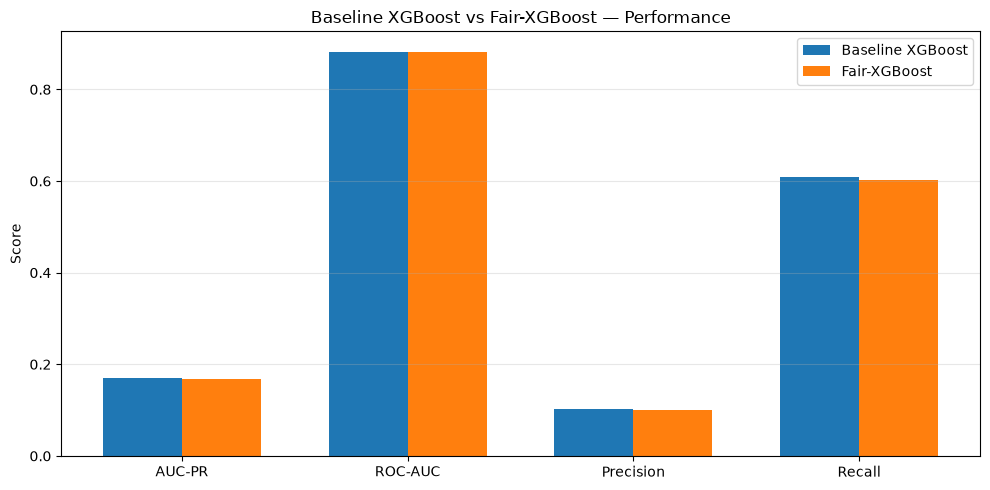

In [54]:
# Performance comparison: Baseline vs Fair-XGBoost

performance_metrics = [
    "AUC-PR",
    "ROC-AUC",
    "Precision",
    "Recall"
]

baseline_values = [
    baseline_metrics["AUC-PR"],
    baseline_metrics["ROC-AUC"],
    baseline_metrics["Precision"],
    baseline_metrics["Recall"]
]

fair_values = [
    fair_metrics["AUC-PR"],
    fair_metrics["ROC-AUC"],
    fair_metrics["Precision"],
    fair_metrics["Recall"]
]

x = np.arange(len(performance_metrics))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(x - width/2, baseline_values, width, label="Baseline XGBoost")
plt.bar(x + width/2, fair_values, width, label="Fair-XGBoost")

plt.xticks(x, performance_metrics)
plt.ylabel("Score")
plt.title("Baseline XGBoost vs Fair-XGBoost — Performance")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

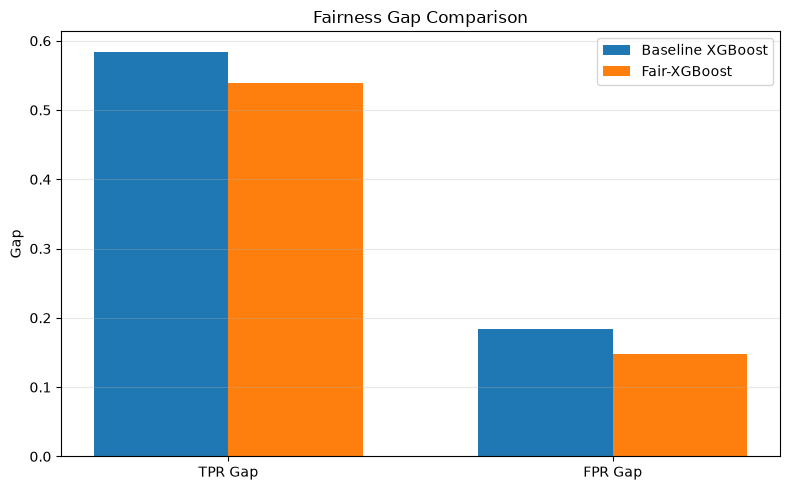

In [55]:
# Fairness gap comparison

fairness_metrics_names = [
    "TPR Gap",
    "FPR Gap"
]

baseline_fairness_values = [
    baseline_tpr_gap,
    baseline_fpr_gap
]

fair_fairness_values = [
    fair_test_tpr_gap,
    fair_test_fpr_gap
]

x = np.arange(len(fairness_metrics_names))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width/2,
    baseline_fairness_values,
    width,
    label="Baseline XGBoost"
)

plt.bar(
    x + width/2,
    fair_fairness_values,
    width,
    label="Fair-XGBoost"
)

plt.xticks(x, fairness_metrics_names)
plt.ylabel("Gap")
plt.title("Fairness Gap Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

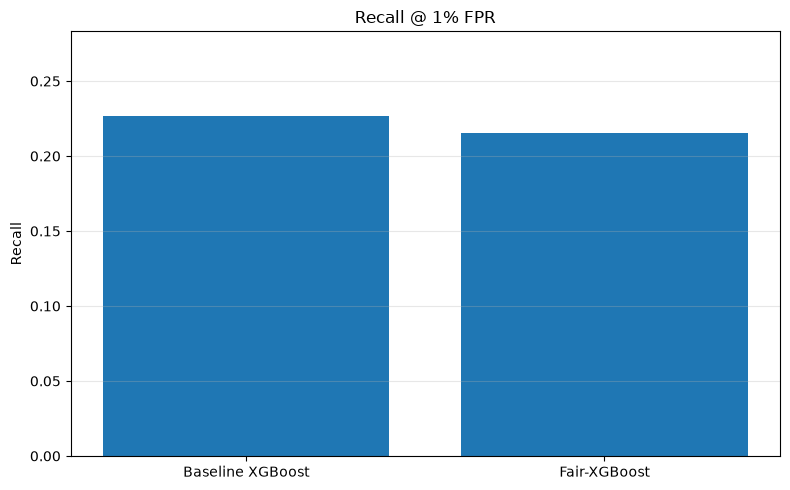

In [56]:
# Recall at 1% FPR comparison

models = [
    "Baseline XGBoost",
    "Fair-XGBoost"
]

recalls = [
    baseline_recall_1fpr,
    fair_test_recall_1fpr
]

plt.figure(figsize=(8, 5))

plt.bar(models, recalls)

plt.ylabel("Recall")
plt.title("Recall @ 1% FPR")
plt.ylim(0, max(recalls) * 1.25)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()